# Analysis - OS experiments

Some notes on the isocpu changes on the bandwidth: Every CPU core on a Linux machine normally belongs to one shared group the scheduler manages together, called a root domain. When you isolate a core with isolcpus, you're pulling it out of that shared group into its own separate group — Linux now tracks scheduling and resource limits for that isolated core independently from the rest of the machine.

One of the things tracked per group is how much bandwidth is set aside for real-time, deadline-based scheduling (SCHED_DEADLINE, which is what KubeDeadline's reservations use under the hood) — but the kernel always keeps a slice of that bandwidth back for ordinary, non-real-time work, so regular processes never get completely frozen out. How big that reserved slice is isn't a fixed percentage of the whole machine — it scales with how many cores are in the group it's protecting. A group with more cores needs a bigger safety reserve, because it has to guarantee ordinary work gets a turn across all of them.

That's the whole story here. On a node that's still isolated, the housekeeping core (the one thing kubelet, sshd, etc. run on) sits alone in its own small group, so its safety reserve is tiny — roughly 5% — leaving about 94% of bandwidth free for real work. On the node where the isolation was deliberately removed as part of testing "what if we take isolation away," that same housekeeping core got folded back into one shared group with the other three cores. Because that combined group is bigger, its safety reserve grows too — up to about 20% — leaving only about 79% free.

So when you strip isolation from a node, you're not just letting more background noise interfere with your workload the way we'd normally expect — you're also structurally shrinking the maximum real-time bandwidth any single reservation can ever get on that node, because the kernel itself needs to set aside more room to protect ordinary processes across the now-larger shared group. That's exactly why the "no isolation" scenario tops out at roughly 79% utilization no matter what you do, while the isolated baseline can go all the way to 94%. It isn't a bug in the driver, isn't bad luck, and isn't something more retries will fix — it's a direct, mechanical side effect of how the kernel accounts for scheduling groups, and it's genuinely worth reporting as a finding in its own right: removing isolation doesn't just add interference, it lowers the ceiling on what's achievable at all.


In [1]:
import pandas as pd
import numpy as np 
import os
import glob
from pathlib import Path
import re
import matplotlib.pyplot as plt
import seaborn as sns

#### Combine data into joined dataset

In [2]:
path = "./os-experiments/analysis/data"
empty = True
origin_data = "./os-experiments/results"
for _ in os.scandir(path):
    empty = False
    break
if empty:
    scenarios = ["01", "02", "03", "04", "05", "06", "07", "08"]
    workloads = ["model1", "model5"]
    combos = [f"{s}-{w}" for s in scenarios for w in workloads]
    
    for combo in combos:
        pieces = []
        round_dirs = sorted(
            glob.glob(os.path.join(origin_data, f"{combo}_round*")),
            key=lambda d: int(re.search(r"_round(\d+)$", d).group(1))
        )
        if not round_dirs:
            print(f"  {combo}: no results dir, skipping")
            continue
        
        for round_dir in round_dirs:
            round_n = int(re.search(r"_round(\d+)$", round_dir).group(1))
            for csv_path in sorted(glob.glob(os.path.join(round_dir, "*", "*", "jobs.csv"))):
                m = re.search(r"/([^/]+)/U([^/]+)/jobs\.csv$", csv_path)
                if not m:
                    print(f"  WARNING: unexpected path shape, skipping: {csv_path}")
                    continue
                scale, u = m.group(1), m.group(2)
                try:
                    df = pd.read_csv(csv_path, comment="#")
                except Exception as e:
                    print(f"  WARNING: could not read {csv_path}: {e}")
                    continue
                if df.empty:
                    print(f"  WARNING: empty csv, skipping: {csv_path}")
                    continue
                df["scenario"] = combo.split("-")[0]
                df["workload"] = combo.split("-")[1]
                df["round"] = round_n
                df["scale"] = scale
                df["U"] = float(u)
                pieces.append(df)
                
        if not pieces:
            print(f"  {combo}: no data found across any round, skipping save")
            continue
            
        combined_dataset = pd.concat(pieces, ignore_index=True)
        combined_dataset.to_csv(os.path.join(path, f"{combo}.csv"), index=False)
        print(f"Saved combined dataset for combo: {combo} ({len(combined_dataset)} rows, "
            f"{combined_dataset['round'].nunique()} round(s))")

Saved combined dataset for combo: 07-model1 (280000 rows, 4 round(s))
Saved combined dataset for combo: 07-model5 (280000 rows, 4 round(s))


#### setup variables

In [7]:
LABELS = {
    "01": "isolcpus removed",
    "02": "nohz_full removed",
    "03": "rcu_nocbs removed",
    "04": "systemd containment removed",
    "05": "IRQ steering removed",
    "06": "boot-params bundle removed",
    "07": "No isolation mechanism at all",
    #ok  but a few things."07": "worst case (everything removed)",
    "08": "frequency pinning removed",
}
CEILING_U = {"01": 0.79, "02": 0.94, "03": 0.94, "04": 0.94, "05": 0.94, "06": 0.94, "07": 0.79, "08": 0.94} #"07": 0.79,
SCENARIO_ORDER = ["01", "02", "03", "04", "05", "06", "07", "08"] #07

PERIOD_US = {"tight": 10000, "soft": 100000}

frames = []
for scenario in SCENARIO_ORDER:
    for workload in ["model1", "model5"]:
        p = os.path.join("./os-experiments/analysis/data", f"{scenario}-{workload}.csv")
        if not os.path.exists(p):
            print(f"missing: {p}"); continue
        df = pd.read_csv(p)
        df["scenario"] = scenario
        df["workload"] = workload
        frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df["normalized_R"] = all_df["R_wall_us"] / (all_df["scale"].map({"tight": 10000, "soft": 100000}))
all_df["deadline_violated"] = all_df["deadline_miss"].astype(bool)
print(f"{len(all_df)} rows, scenarios={sorted(all_df.scenario.unique())}, workloads={sorted(all_df.workload.unique())}")

5880000 rows, scenarios=['01', '02', '03', '04', '05', '06', '07', '08'], workloads=['model1', 'model5']


#### Tornado chart - sensitivity ranking

baseline: 1190000 rows, workloads=['model1', 'model5']


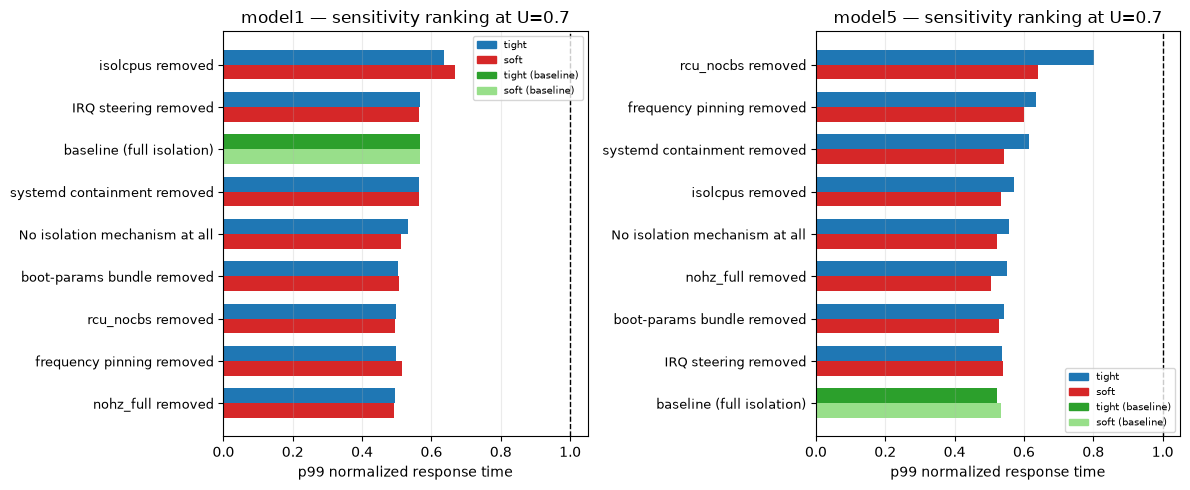

In [8]:
BASELINE_MODEL_DIR = {"model1": "model1", "model5": "model5-phys"}   # confirm model1 mapping above
baseline_frames = []
for workload, dirname in BASELINE_MODEL_DIR.items():
    df = pd.read_csv(f"./kubedeadline-experiments/analysis/data/{dirname}.csv")
    df["workload"] = workload
    baseline_frames.append(df)
    
baseline_df = pd.concat(baseline_frames, ignore_index=True)
baseline_df["normalized_R"] = baseline_df["R_wall_us"] / baseline_df["scale"].map(PERIOD_US)
print(f"baseline: {len(baseline_df)} rows, workloads={sorted(baseline_df.workload.unique())}")

FIXED_U = 0.7   # reachable by every scenario, including the 01 (0.79) ceiling

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, workload in zip(axes, ["model1", "model5"]):
    stats = []
    for scenario in SCENARIO_ORDER:
        sub = all_df[(all_df.workload == workload) & (all_df.U == FIXED_U) & (all_df.scenario == scenario)]
        if sub.empty:
            continue
        p99 = sub.groupby("scale")["normalized_R"].quantile(0.99)
        stats.append({"scenario": scenario, "label": LABELS[scenario], "is_baseline": False,
                    "p99_tight": p99.get("tight", float("nan")),
                    "p99_soft": p99.get("soft", float("nan"))})
                    
    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U == FIXED_U)]
    if not base_sub.empty:
        p99_base = base_sub.groupby("scale")["normalized_R"].quantile(0.99)
        stats.append({"scenario": "baseline", "label": "baseline (full isolation)", "is_baseline": True,
                    "p99_tight": p99_base.get("tight", float("nan")),
                    "p99_soft": p99_base.get("soft", float("nan"))})
                    
    sdf = pd.DataFrame(stats).sort_values("p99_tight", ascending=True)
    y = np.arange(len(sdf))
    height = 0.35
    tight_colors = ["#2ca02c" if b else "#1f77b4" for b in sdf["is_baseline"]]
    soft_colors = ["#98df8a" if b else "#d62728" for b in sdf["is_baseline"]]
    ax.barh(y + height/2, sdf["p99_tight"], height, color=tight_colors)
    ax.barh(y - height/2, sdf["p99_soft"], height, color=soft_colors)
    ax.set_yticks(list(y)); ax.set_yticklabels(sdf["label"], fontsize=9)
    ax.axvline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("p99 normalized response time")
    ax.set_title(f"{workload} — sensitivity ranking at U={FIXED_U}")
    
    handles = [plt.Rectangle((0,0),1,1, color="#1f77b4"), plt.Rectangle((0,0),1,1, color="#d62728"),
                plt.Rectangle((0,0),1,1, color="#2ca02c"), plt.Rectangle((0,0),1,1, color="#98df8a")]
    ax.legend(handles, ["tight", "soft", "tight (baseline)", "soft (baseline)"], fontsize=7)
    ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
plt.show()


#### Tornado Chart Execution Time

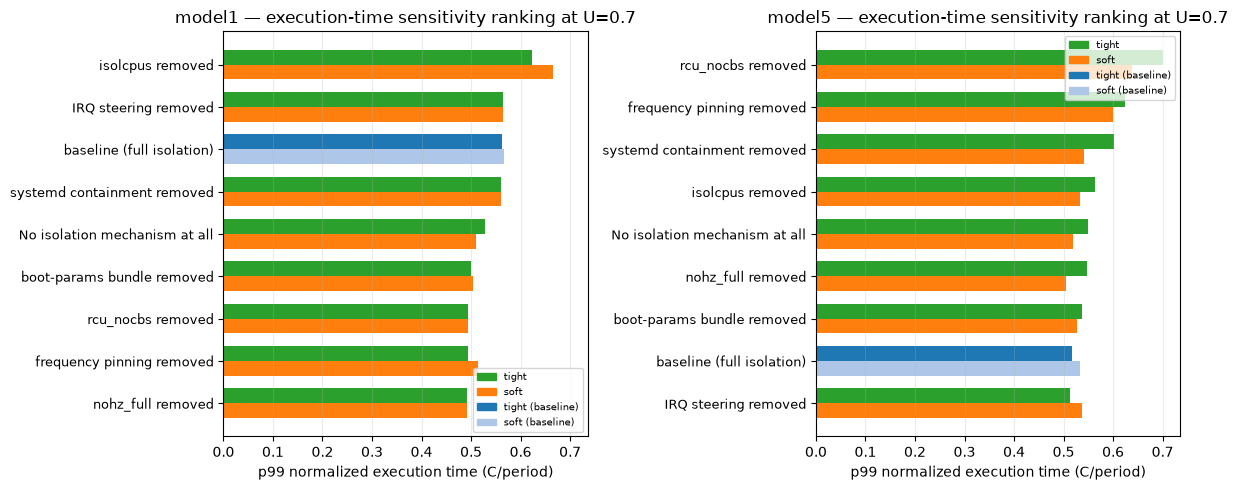

In [9]:
all_df["normalized_C"] = all_df["C_cputime_us"] / all_df["scale"].map({"tight": 10000, "soft": 100000})
baseline_df["normalized_C"] = baseline_df["C_cputime_us"] / baseline_df["scale"].map(PERIOD_US)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, workload in zip(axes, ["model1", "model5"]):
    stats = []
    for scenario in SCENARIO_ORDER:
        sub = all_df[(all_df.workload == workload) & (all_df.U == FIXED_U) & (all_df.scenario == scenario)]
        if sub.empty:
            continue
        p99 = sub.groupby("scale")["normalized_C"].quantile(0.99)
        stats.append({"scenario": scenario, "label": LABELS[scenario], "is_baseline": False,
                    "p99_tight": p99.get("tight", float("nan")),
                    "p99_soft": p99.get("soft", float("nan"))})
    
    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U == FIXED_U)]
    if not base_sub.empty:
        p99_base = base_sub.groupby("scale")["normalized_C"].quantile(0.99)
        stats.append({"scenario": "baseline", "label": "baseline (full isolation)", "is_baseline": True,
                    "p99_tight": p99_base.get("tight", float("nan")),
                    "p99_soft": p99_base.get("soft", float("nan"))})
    
    sdf = pd.DataFrame(stats).sort_values("p99_tight", ascending=True)
    y = np.arange(len(sdf))
    height = 0.35
    tight_colors = ["#1f77b4" if b else "#2ca02c" for b in sdf["is_baseline"]]
    soft_colors = ["#aec7e8" if b else "#ff7f0e" for b in sdf["is_baseline"]]
    ax.barh(y + height/2, sdf["p99_tight"], height, color=tight_colors)
    ax.barh(y - height/2, sdf["p99_soft"], height, color=soft_colors)
    ax.set_yticks(list(y)); ax.set_yticklabels(sdf["label"], fontsize=9)
    ax.set_xlabel("p99 normalized execution time (C/period)")
    ax.set_title(f"{workload} — execution-time sensitivity ranking at U={FIXED_U}")
    
    handles = [plt.Rectangle((0,0),1,1, color="#2ca02c"), plt.Rectangle((0,0),1,1, color="#ff7f0e"),
                plt.Rectangle((0,0),1,1, color="#1f77b4"), plt.Rectangle((0,0),1,1, color="#aec7e8")]
    ax.legend(handles, ["tight", "soft", "tight (baseline)", "soft (baseline)"], fontsize=7)
    ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
plt.show()


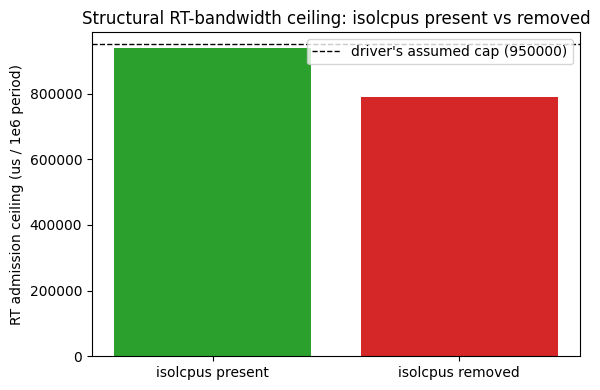

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["isolcpus present", "isolcpus removed"], [940000, 790003], color=["#2ca02c", "#d62728"])
ax.axhline(950000, color="black", linestyle="--", linewidth=1, label="driver's assumed cap (950000)")
ax.set_ylabel("RT admission ceiling (us / 1e6 period)")
ax.set_title("Structural RT-bandwidth ceiling: isolcpus present vs removed")
ax.legend()
plt.tight_layout(); plt.show()


#### Tornado with at Utilization 94%

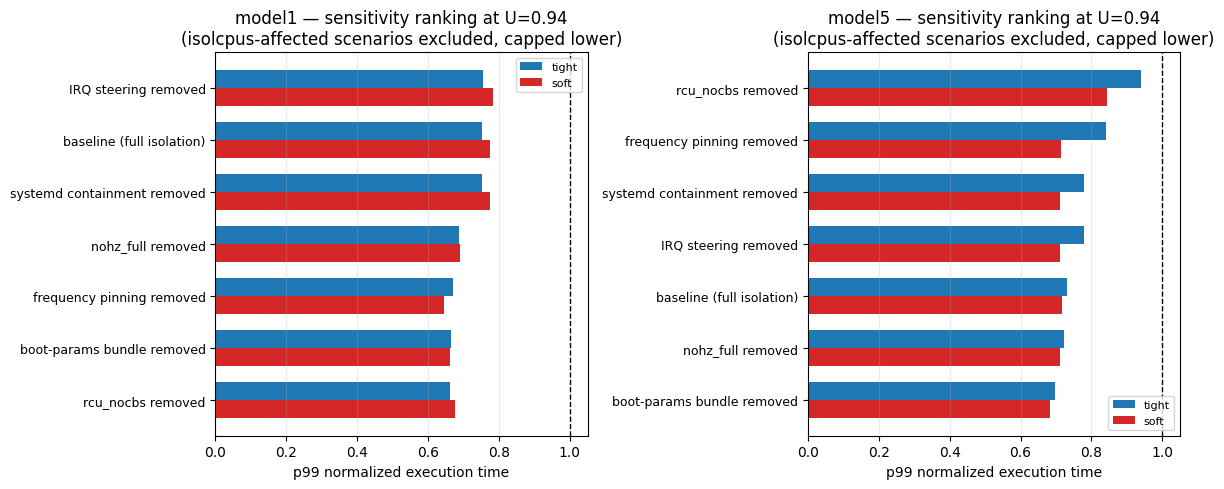

In [7]:
FIXED_U_HIGH = 0.94                                                                                                                                                                         
EXCLUDE_AT_HIGH_U = {"01", "07"}   # can't reach 0.94, capped by the isolcpus ceiling                                                                                                       
                                                                                                                                                                                            
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)                                                                                                                                
for ax, workload in zip(axes, ["model1", "model5"]):                                                                                                                                        
    stats = []                                                                                                                                                                              
    for scenario in SCENARIO_ORDER:                                                                                                                                                         
        if scenario in EXCLUDE_AT_HIGH_U:                                                                                                                                                   
            continue                                                                                                                                                                        
        sub = all_df[(all_df.workload == workload) & (all_df.U == FIXED_U_HIGH) & (all_df.scenario == scenario)]                                                                            
        if sub.empty:                                                                                                                                                                       
            continue                                                                                                                                                                        
        p99 = sub.groupby("scale")["normalized_R"].quantile(0.99)                                                                                                                           
        stats.append({"scenario": scenario, "label": LABELS[scenario],                                                                                                                      
                    "p99_tight": p99.get("tight", float("nan")),                                                                                                                          
                    "p99_soft": p99.get("soft", float("nan"))})                                                                                                                           
                                                                                                                                                                                            
    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U == FIXED_U_HIGH)]                                                                                            
    if not base_sub.empty:                                                                                                                                                                  
        p99_base = base_sub.groupby("scale")["normalized_C"].quantile(0.99)                                                                                                                 
        stats.append({"scenario": "baseline", "label": "baseline (full isolation)",                                                                                                         
                    "p99_tight": p99_base.get("tight", float("nan")),                                                                                                                     
                    "p99_soft": p99_base.get("soft", float("nan"))})                                                                                                                      
                                                                                                                                                                                            
    sdf = pd.DataFrame(stats).sort_values("p99_tight", ascending=True)                                                                                                                      
    y = np.arange(len(sdf))                                                                                                                                                                 
    height = 0.35                                                                                                                                                                           
    ax.barh(y + height/2, sdf["p99_tight"], height, color="#1f77b4", label="tight")                                                                                                         
    ax.barh(y - height/2, sdf["p99_soft"], height, color="#d62728", label="soft")                                                                                                           
    ax.set_yticks(list(y)); ax.set_yticklabels(sdf["label"], fontsize=9)                                                                                                                    
    ax.axvline(1.0, color="black", linewidth=1, linestyle="--")                                                                                                                             
    ax.set_xlabel("p99 normalized execution time")                                                                                                                                           
    ax.set_title(f"{workload} — sensitivity ranking at U={FIXED_U_HIGH}\n(isolcpus-affected scenarios excluded, capped lower)")                                                             
    ax.legend(fontsize=8)                                                                                                                                                                   
    ax.grid(alpha=0.25, axis="x")                                                                                                                                                           
fig.tight_layout()                                                                                                                                                                          
plt.show()   

#### Normalized Response time

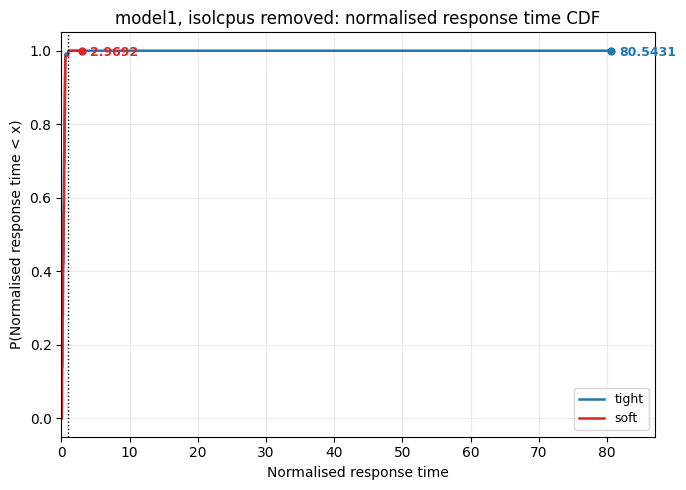

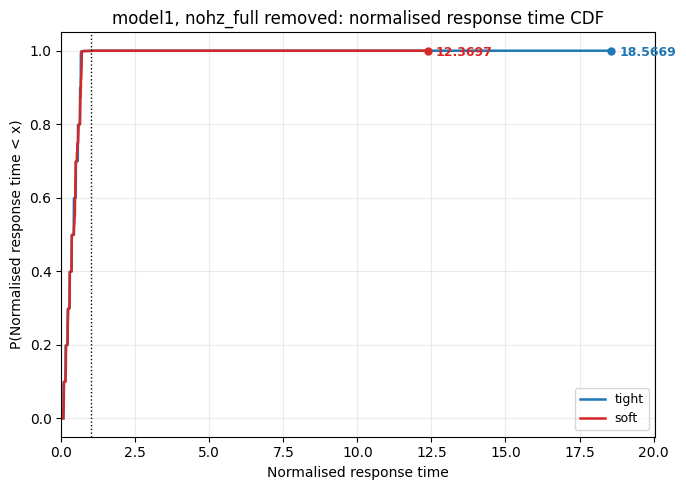

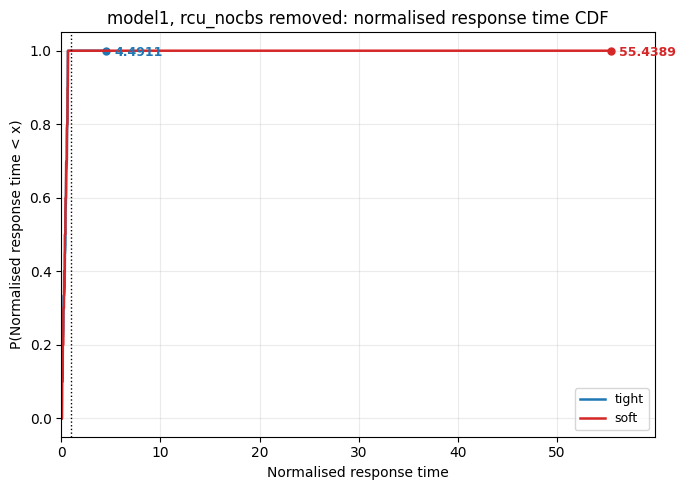

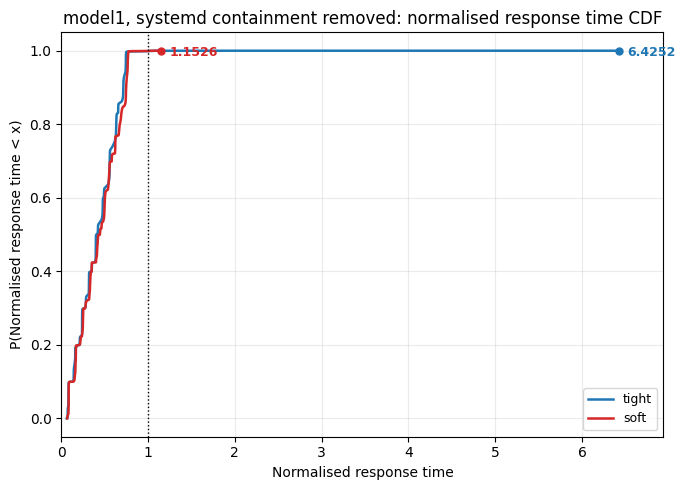

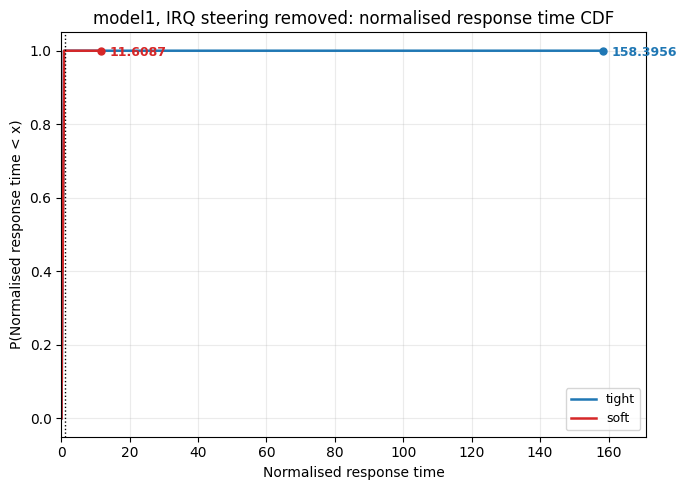

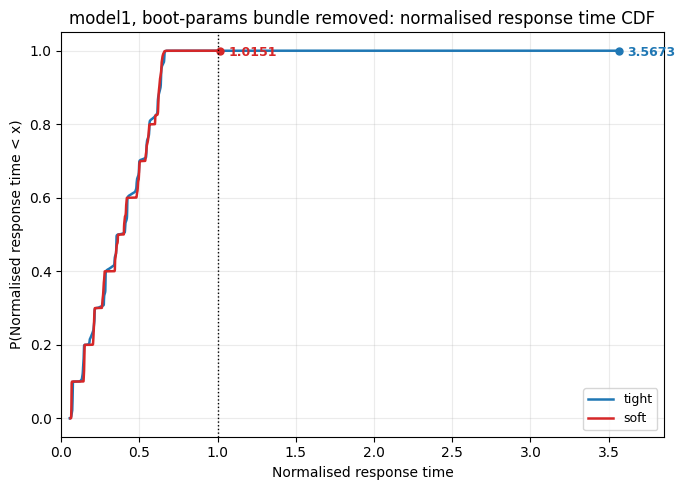

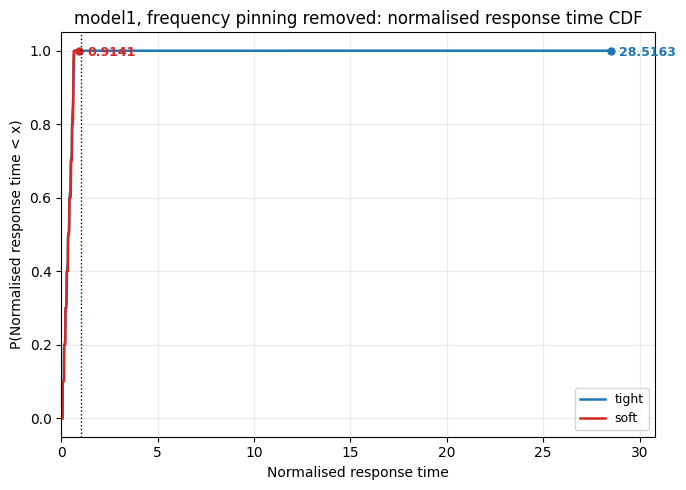

In [8]:
def plot_normalized_R_cdf_single(label, df, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    x_ends = []
    for scale, color in [("tight", "#1f77b4"), ("soft", "#d62728")]:
        sub = df[df.scale == scale]
        x = np.sort(sub["normalized_R"].values)
        y = np.arange(1, len(x) + 1) / len(x)
        ax.plot(x, y, color=color, linewidth=1.8, label=scale)

        x_end = x[-1]
        x_ends.append(x_end)
        ax.plot(x_end, 1.0, "o", color=color, markersize=5)
        ax.annotate(f"{x_end:.4f}", xy=(x_end, 1.0), xytext=(6, -4),
                    textcoords="offset points", color=color, fontsize=9, fontweight="bold")

    ax.axvline(1.0, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("Normalised response time")
    ax.set_ylabel("P(Normalised response time < x)")
    ax.set_title(title)
    ax.set_xlim(0, max(x_ends) * 1.08)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="lower right")
    fig.tight_layout()

# model1: one figure per scenario (6 figures)
for scenario in SCENARIO_ORDER:
    p = os.path.join("./os-experiments/analysis/data", f"{scenario}-model1.csv")
    if not os.path.exists(p):
        print(f"missing: {p}"); continue 
    df = pd.read_csv(p)
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    plot_normalized_R_cdf_single(LABELS[scenario], df,
                                f"model1, {LABELS[scenario]}: normalised response time CDF")


#### CDF Multi-Core

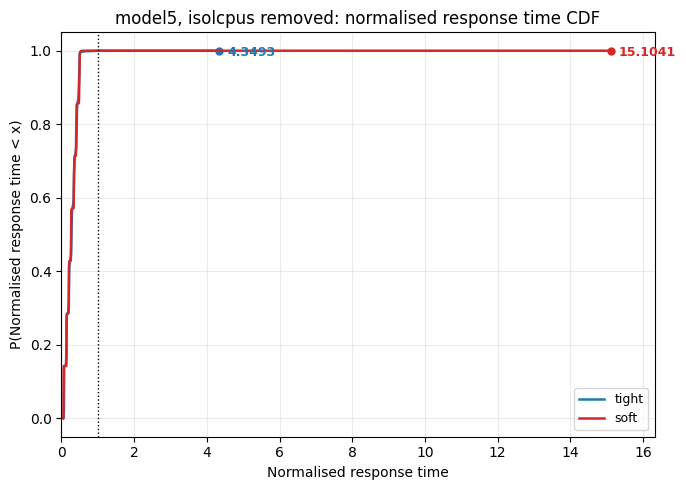

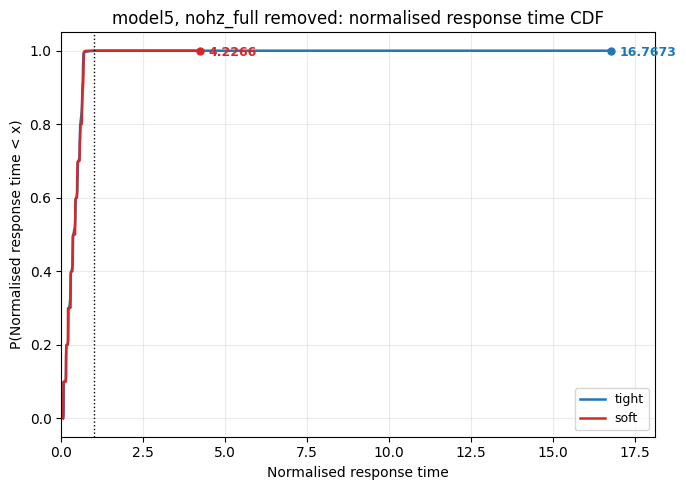

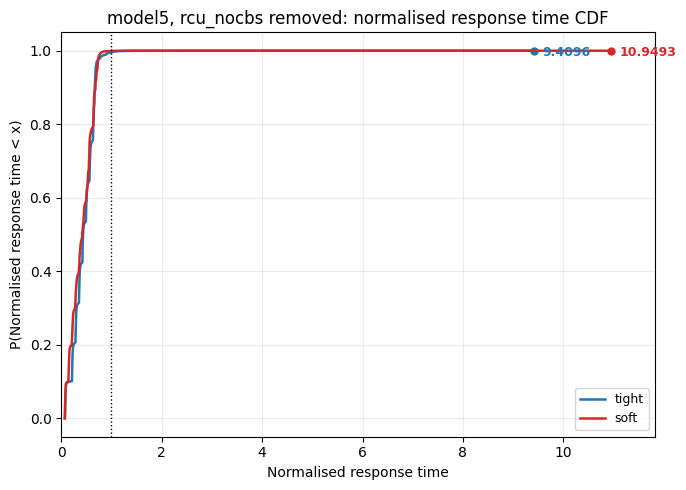

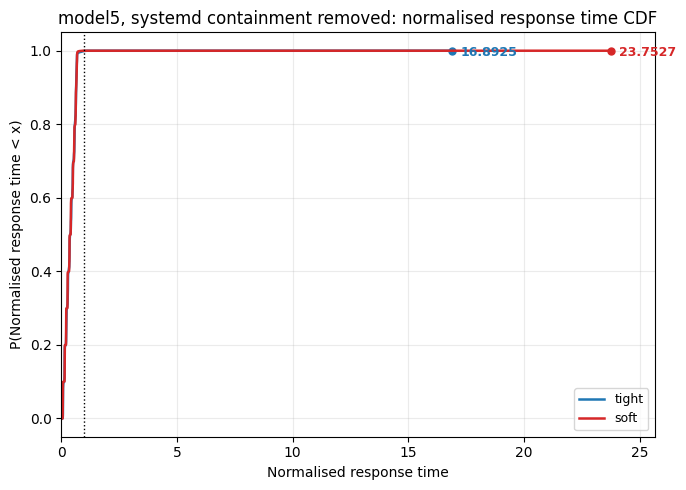

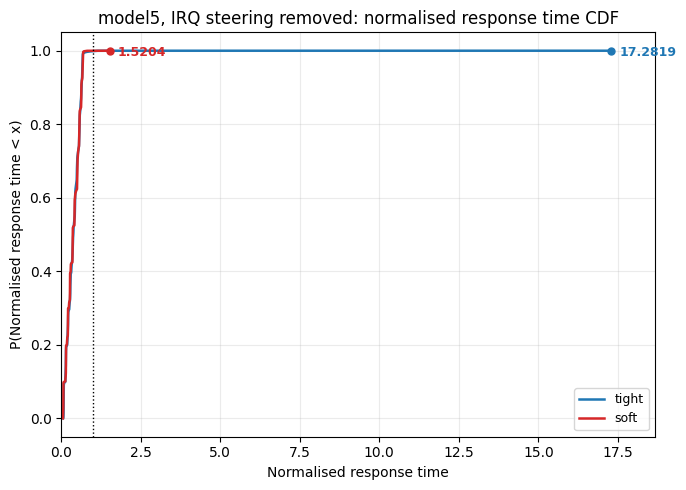

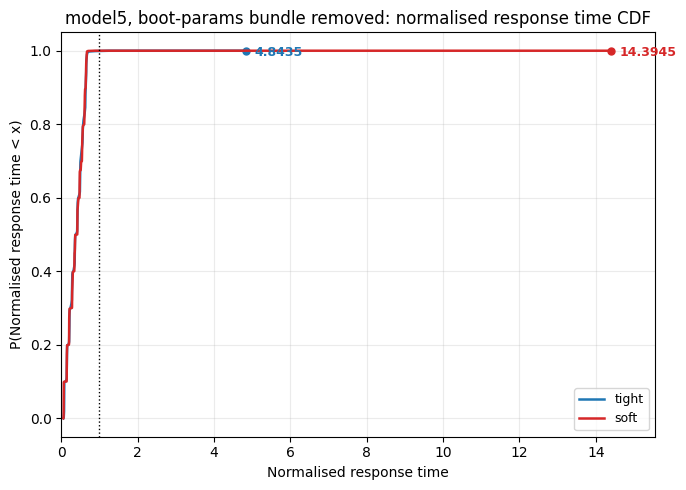

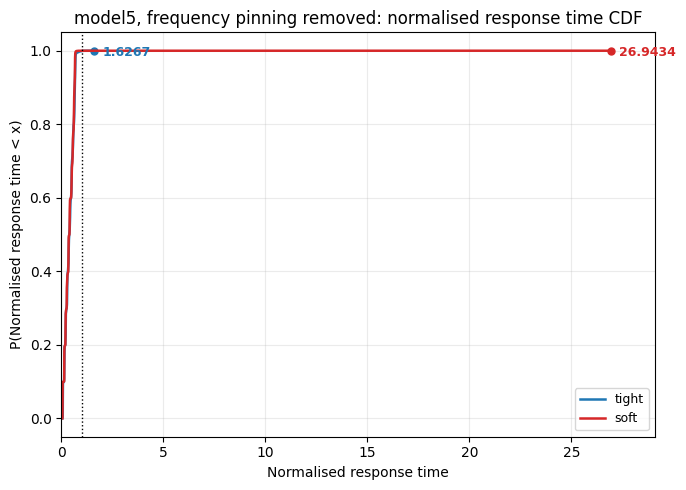

In [9]:
for scenario in SCENARIO_ORDER:
    p = os.path.join("./os-experiments/analysis/data", f"{scenario}-model5.csv")
    if not os.path.exists(p):
        print(f"missing: {p}"); continue
    df = pd.read_csv(p)
    df["normalized_R"] = df["R_wall_us"] / df["scale"].map(PERIOD_US)
    plot_normalized_R_cdf_single(LABELS[scenario], df,
                                f"model5, {LABELS[scenario]}: normalised response time CDF")


#### Distribution of tehe Response time

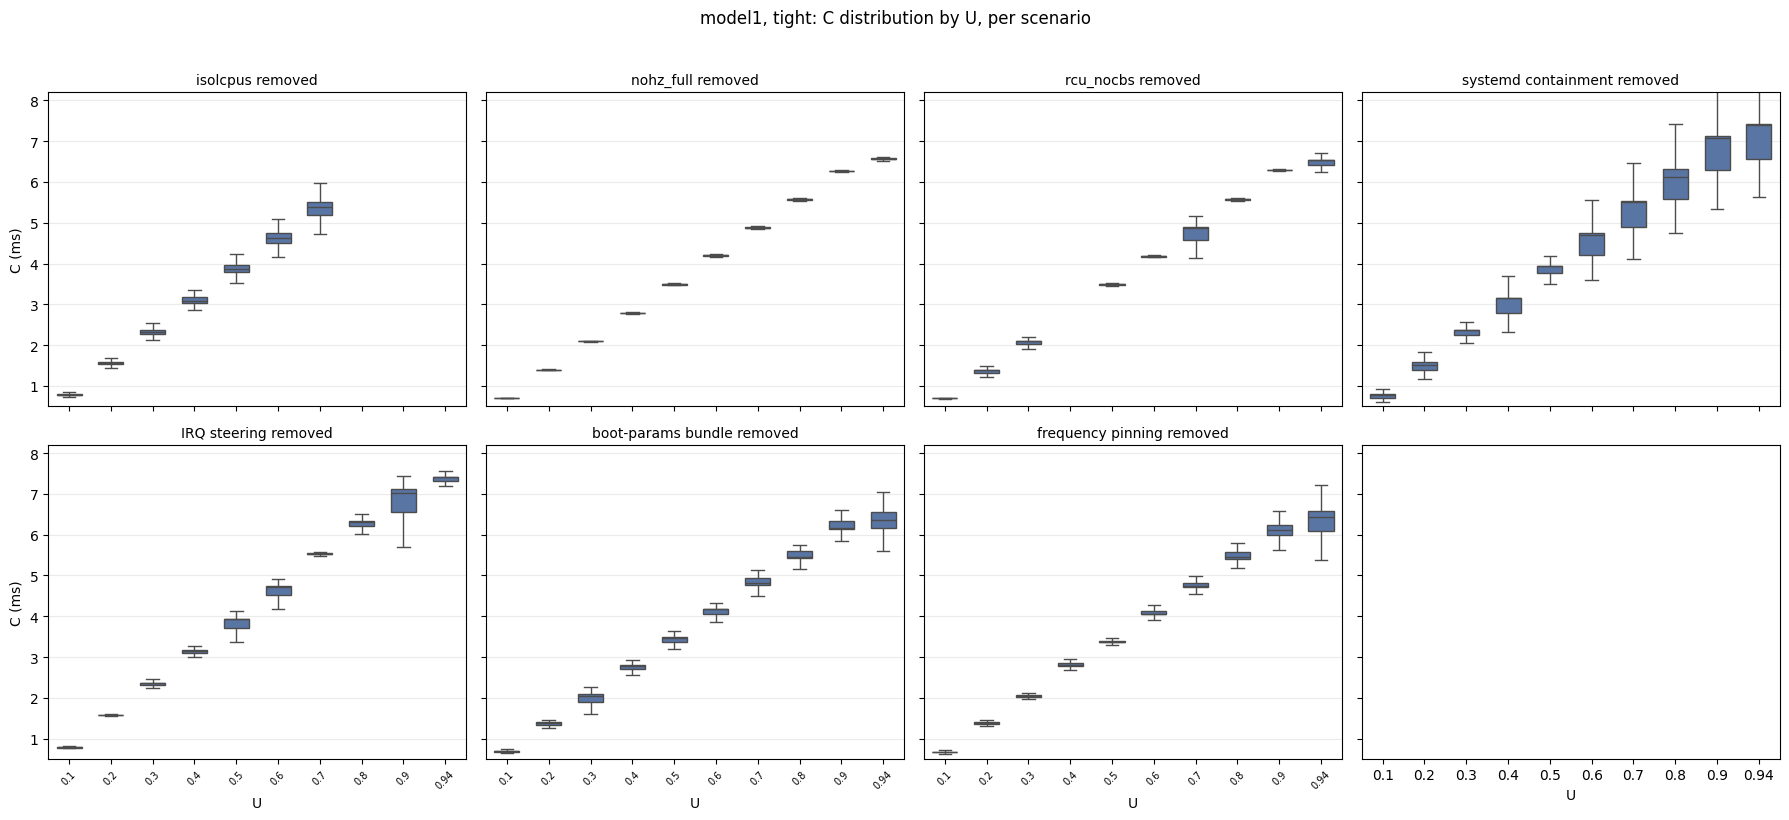

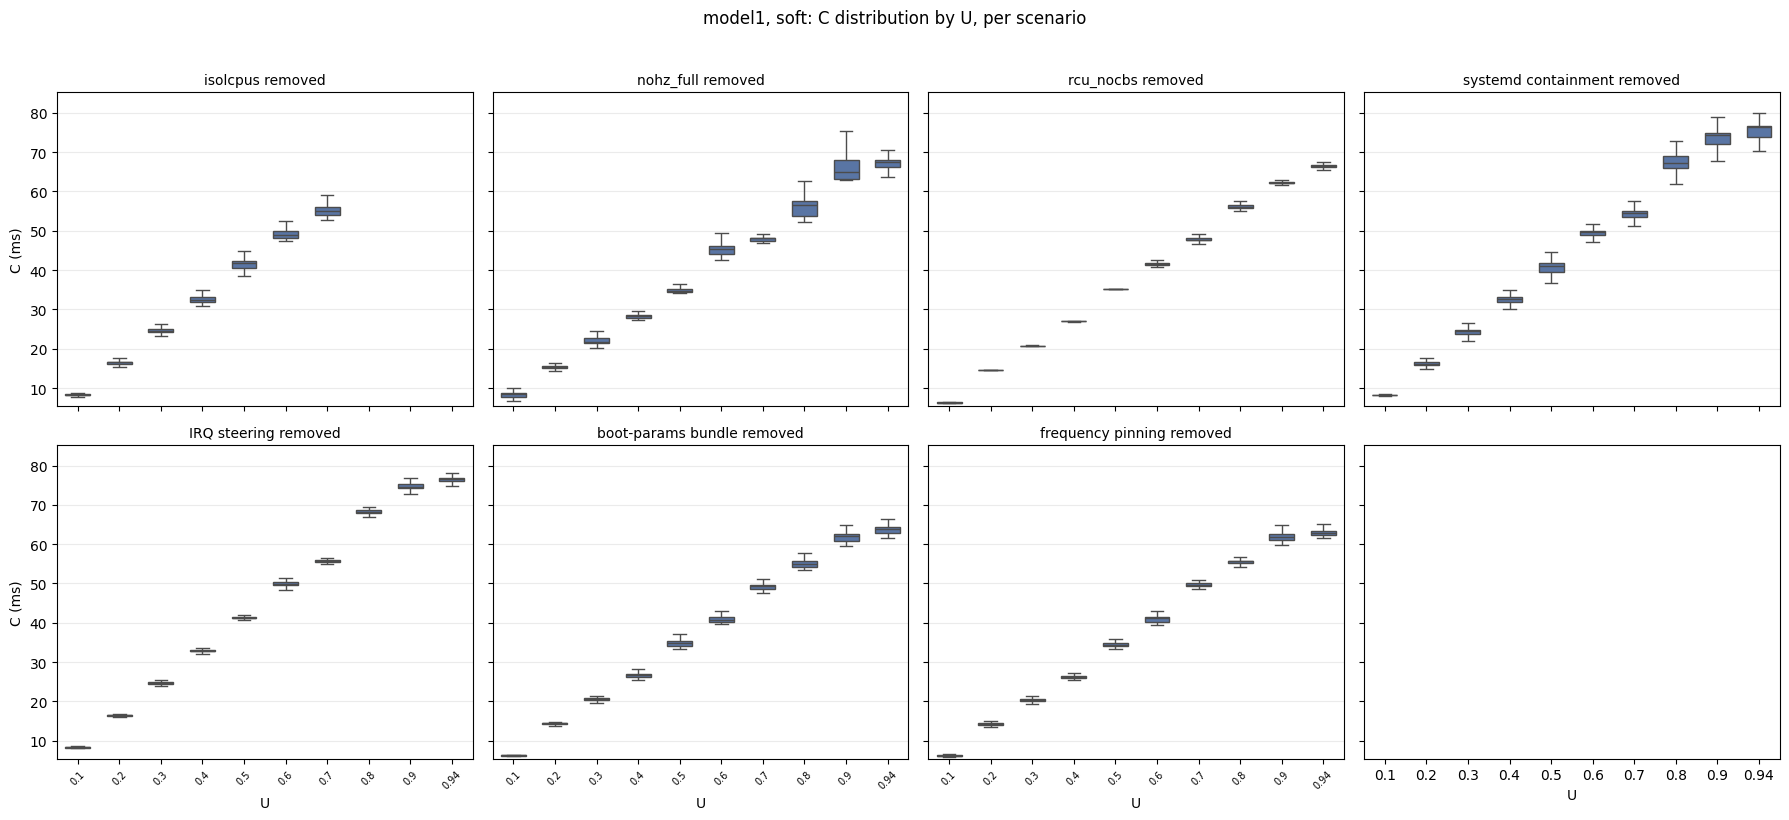

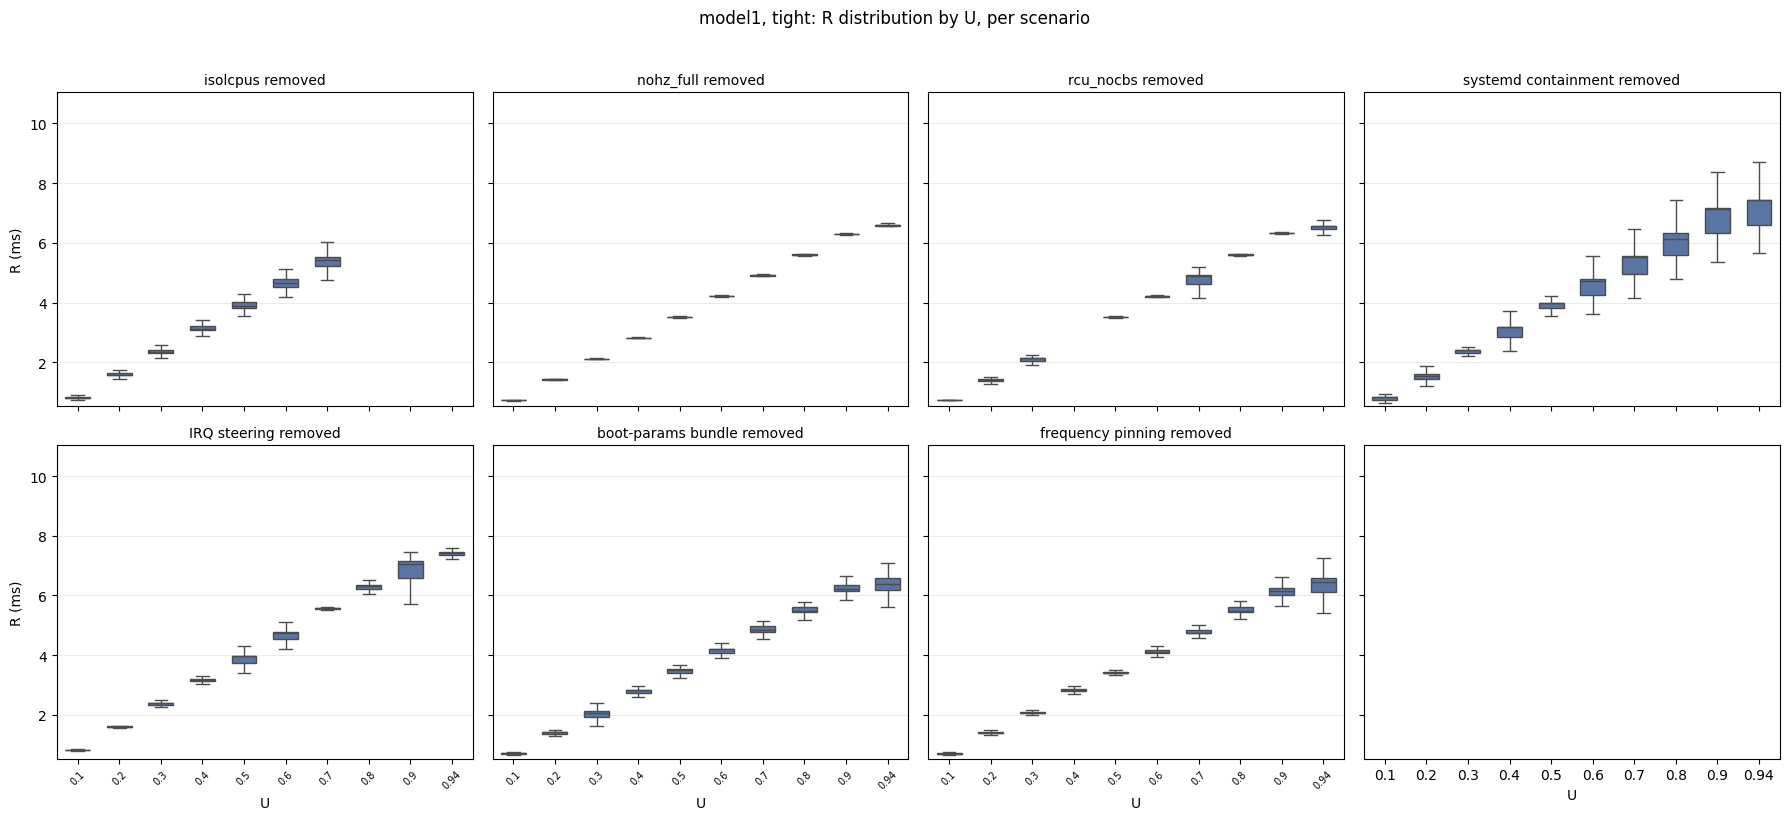

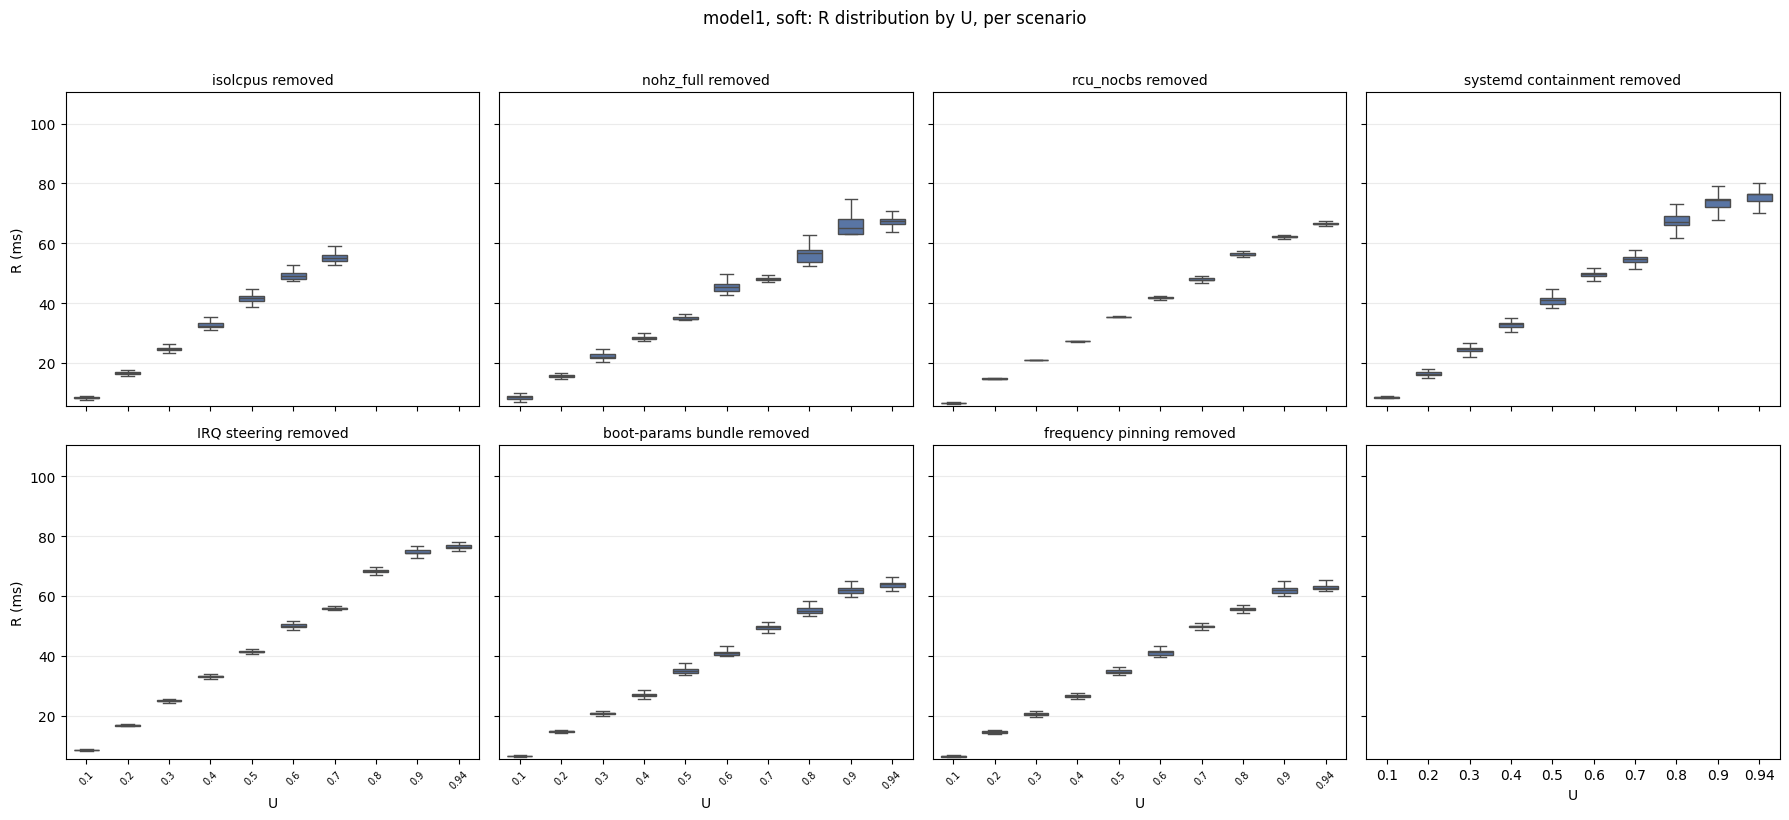

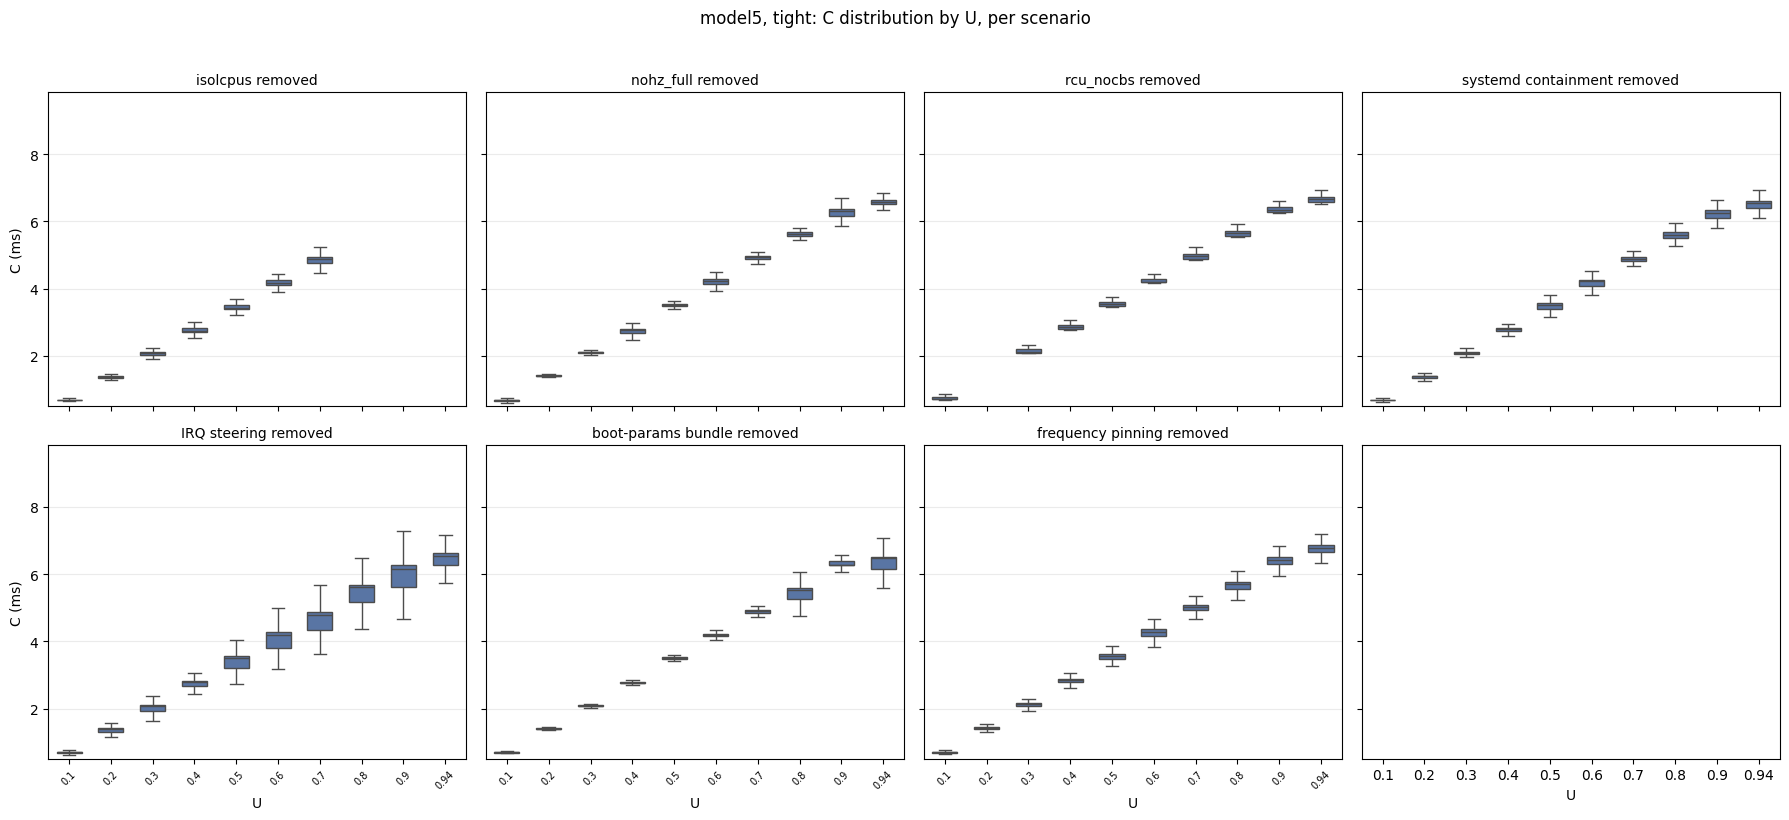

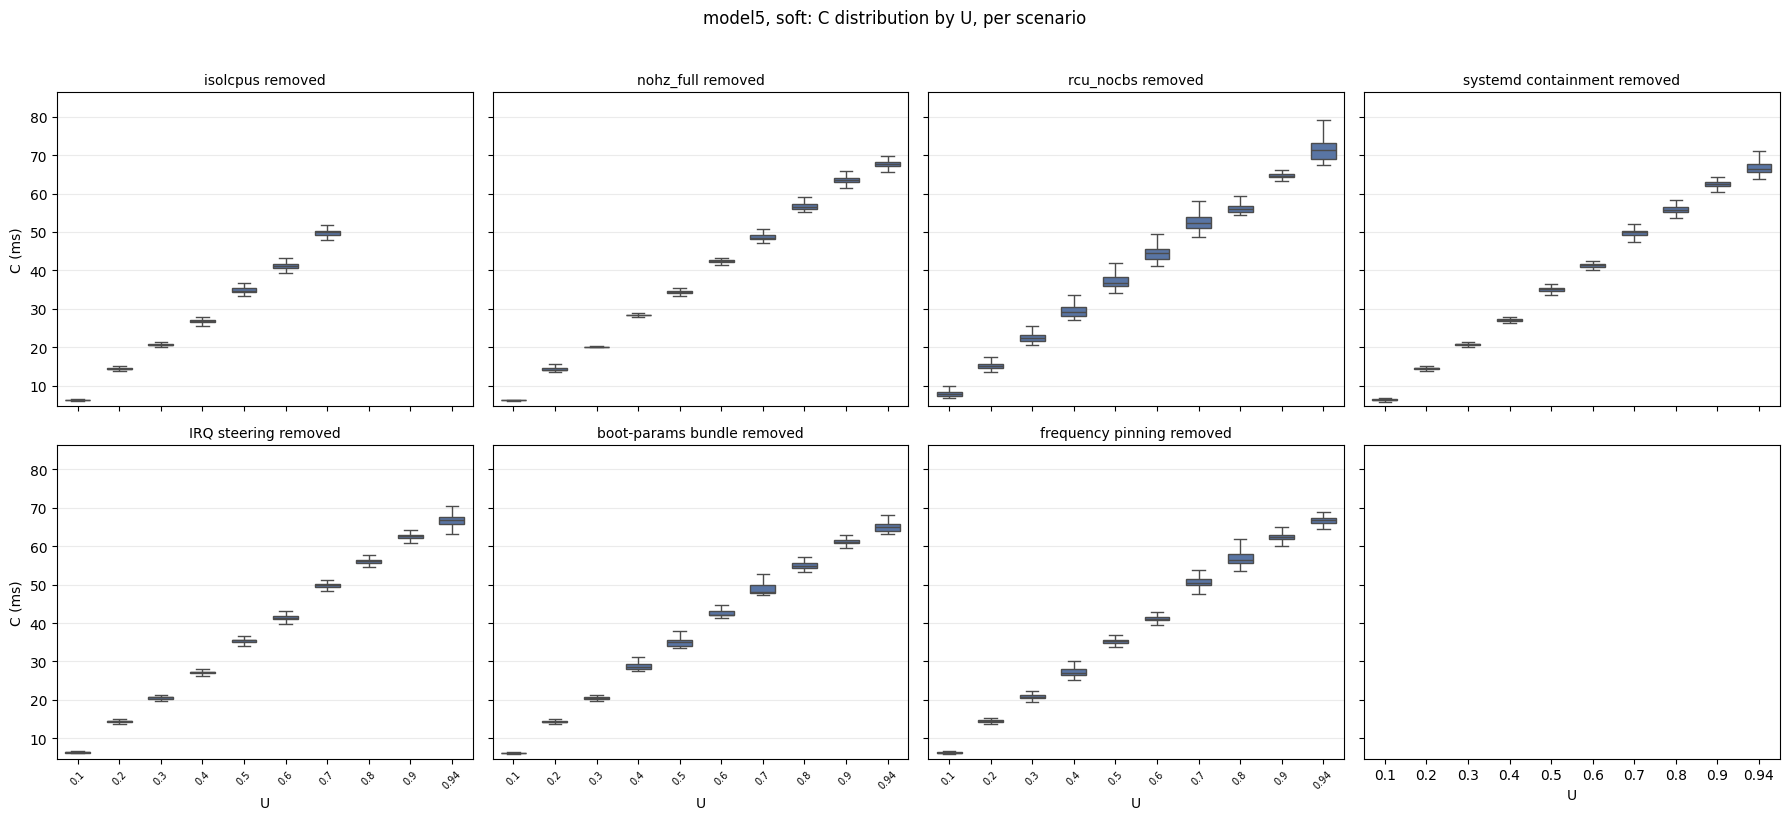

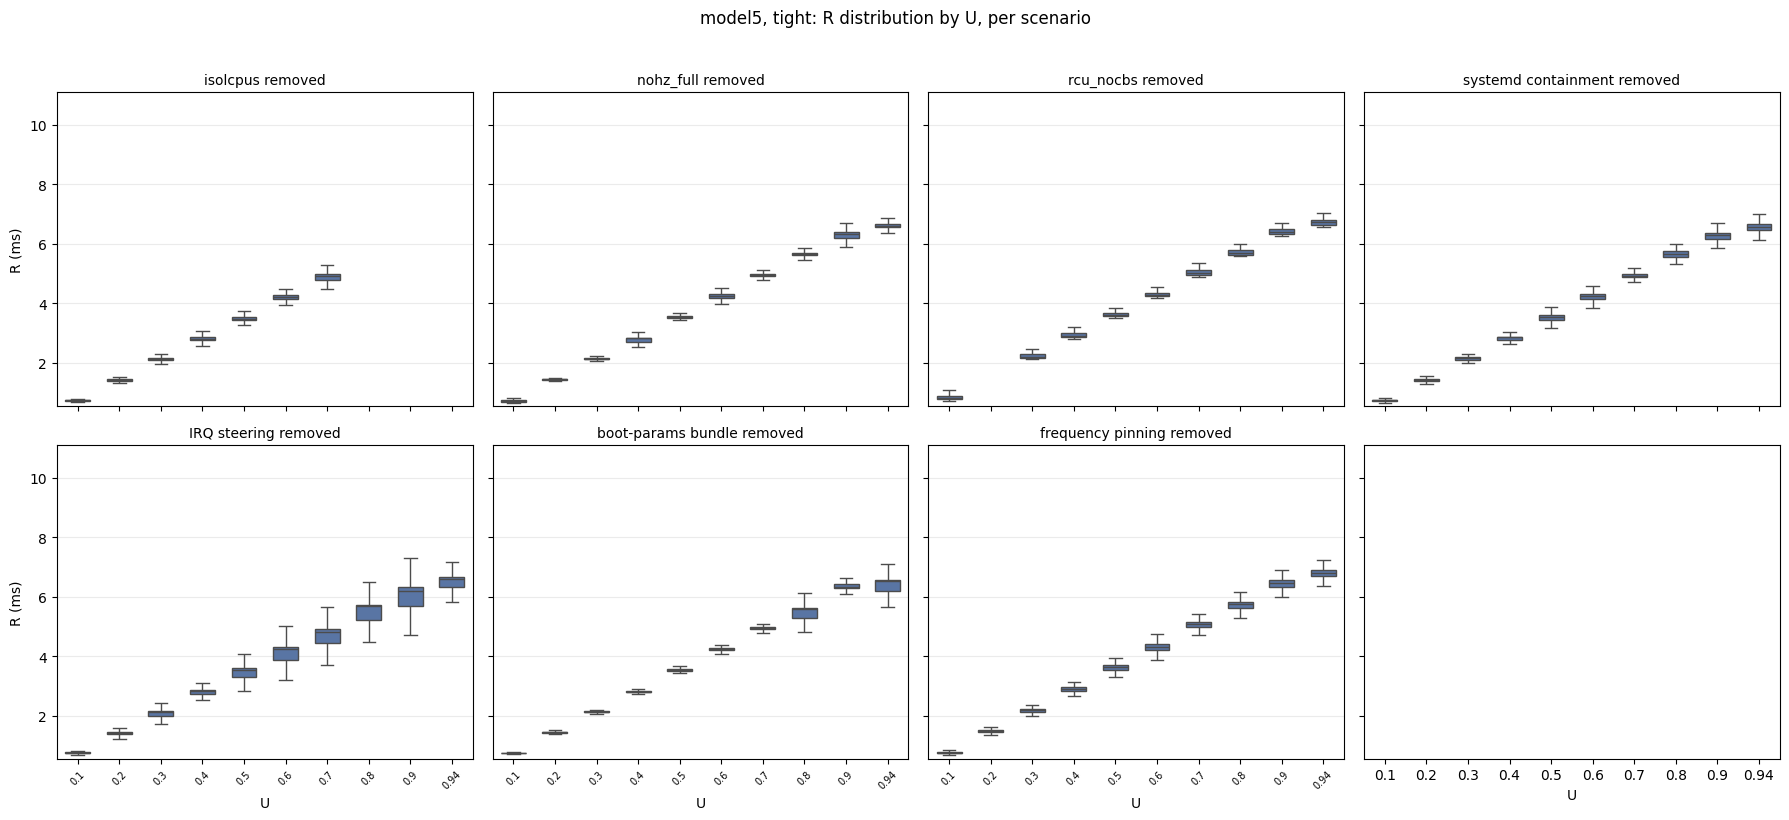

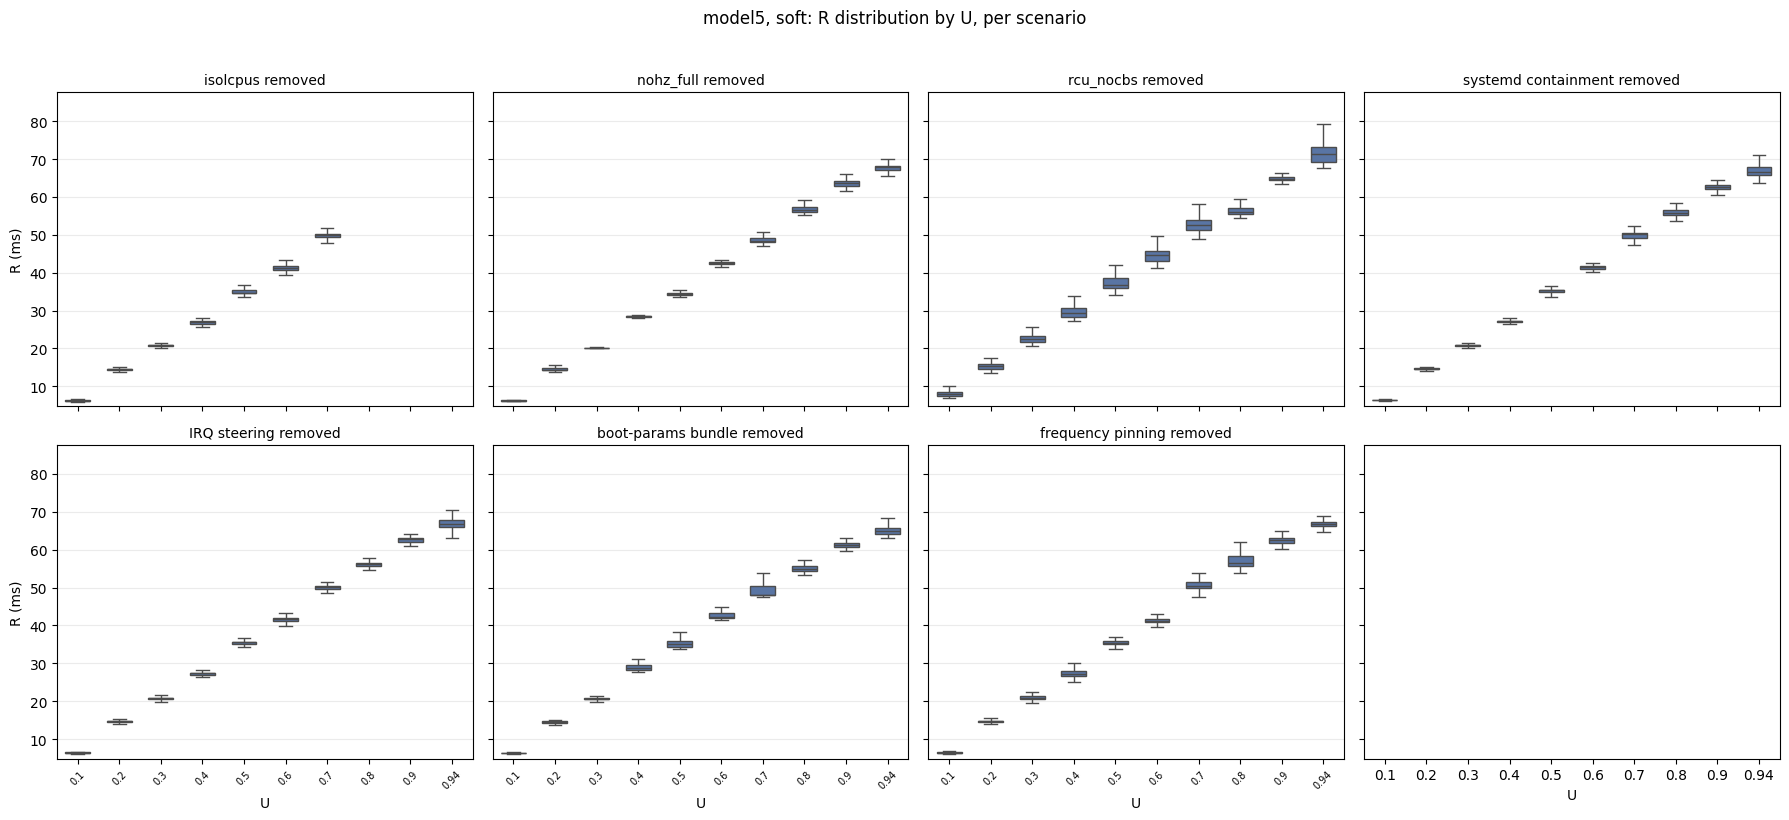

In [10]:
for workload in ["model1", "model5"]:
    wl_df = all_df[all_df.workload == workload].copy()
    
    for metric_col, metric_label in [("C_cputime_us", "C"), ("R_wall_us", "R")]:
        for scale in ["tight", "soft"]: 
            plot_df = wl_df[wl_df.scale == scale].copy()
            plot_df["value_ms"] = plot_df[metric_col] / 1000.0
            
            fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True, sharex=True)
            y_min = plot_df["value_ms"].quantile(0.001)
            y_max = plot_df["value_ms"].quantile(0.999)
            
            for ax, scenario in zip(axes.flat, SCENARIO_ORDER):
                sub = plot_df[plot_df.scenario == scenario]
                if sub.empty:
                    ax.set_title(f"{LABELS[scenario]} (no data)", fontsize=10)
                    ax.axis("off")
                    continue
                sns.boxplot(data=sub, x="U", y="value_ms", ax=ax,
                            color="#4c72b0", showfliers=False, width=0.6)
                ax.set_title(LABELS[scenario], fontsize=10)
                ax.set_xlabel("")
                ax.set_ylabel(f"{metric_label} (ms)" if ax in axes[:, 0] else "")
                ax.tick_params(axis="x", labelsize=7, rotation=45)
                ax.grid(alpha=0.25, axis="y")
            
            for ax in axes[-1, :]:
                ax.set_xlabel("U")
            axes.flat[0].set_ylim(y_min * 0.9, y_max * 1.1)
            
            fig.suptitle(f"{workload}, {scale}: {metric_label} distribution by U, per scenario", y=1.02)
            fig.tight_layout()
            plt.show()

#### Distribution table + deadline miss probability table (block bootstrap CI)

Block bootstrap (block=100 jobs) instead of resampling individual jobs, since
response times on a shared VM are correlated over time — plain binomial/i.i.d.
CIs would be too narrow. `block_bootstrap_ci` resamples contiguous 100-job
blocks (jobs already sorted by round/job_index so blocks stay time-contiguous)
and returns the empirical 95% interval of the given statistic under that
resampling. Reused below for both the p99 tail CI (Step 1) and the miss-rate
CI (Step 2, compared directly against the classic Wilson interval — if they
diverge a lot, that's itself evidence misses are bursty, not independent).

#### Observed (m,k) table + breakdown utilization

Step 3: for each (scenario, workload, scale, U, round), slide a window of k
consecutive jobs over the met/missed sequence (ordered by job_index, never
crossing a round boundary -- separate rounds are separate runs, a window
spanning the join would be an artifact). Observed m = the minimum window sum
across all windows and all rounds (worst case). Compared against the 5th
percentile of the minimum window sum under i.i.d. Bernoulli(measured miss
rate) simulation -- if observed m is clearly below that, misses cluster
(matches/contradicts the `ci_gap` finding from Step 2, which found no
evidence of clustering at block=100; k=10/100 here is a finer-grained check).

Step 4: breakdown utilization = highest U where the upper CI bound
(`block_boot_hi`, the time-correlation-aware one) of the miss probability
stays below tolerance eps (1% and 5%). Interpolated between the two
neighbouring tested U values on the logit scale (miss curves rise steeply,
so linear interpolation on the raw scale would overshoot). Same idea applied
to the (m,k) criterion, with target m derived from the same eps grid:
`target_m = floor((1-eps)*k)` -- e.g. eps=5%, k=100 -> target m=95 -- so both
criteria are directly comparable at the same tolerance level.

#### Distribution table, presentation layout

One table per model (model1 = single-core, model5 = multi-core), one per
metric (R = response time, C = execution time). Rows blocked by scenario
(`label` only, no separate `scenario` column), scale (tight/soft) as the row
sub-level within each block. Columns: one group per U, with
min/p25/median/mean/p75/p95/p99/max nested underneath -- no std/cv, no CI
(CI stays in the underlying `dist_table_R`/`dist_table_C` CSVs).